In [343]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [344]:
db_path = "../Data/logs_output.db"
conn = sqlite3.connect(db_path)

In [345]:
sql_query = "SELECT * FROM log_record"

In [346]:
df = pd.read_sql_query(sql_query, conn)

In [347]:
df.head()

,timestamp,level,user_id,action,latency_ms,error_code
0,2026-09-29 21:50:37,INFO,user_577,login,25,0
1,2026-09-29 21:50:39,INFO,user_604,login,94,0
2,2026-09-29 21:50:42,WARN,user_373,add_cart,99,0
3,2026-09-29 21:50:45,INFO,user_366,add_cart,65,0
4,2026-09-29 21:50:48,INFO,user_12,add_cart,28,0


In [348]:
df["level"].value_counts()

level
INFO     8992
WARN      510
ERROR     498
Name: count, dtype: int64

In [349]:
df["action"].value_counts()

action
login        2545
add_cart     2522
view_item    2496
pay          2437
Name: count, dtype: int64

In [350]:
df["latency_ms"].mean()

np.float64(111.9568)

In [351]:
df["latency_ms"].median()

np.float64(62.0)

In [352]:
df["latency_ms"].max()

np.int64(1499)

In [353]:
df["latency_ms"].min()

np.int64(20)

In [354]:
df["latency_ms"].quantile(0.95)

np.float64(100.0)

In [355]:
df.groupby("action")["latency_ms"].agg(["mean", "max"])

,mean,max
action,,
add_cart,112.664552,1483
login,112.791356,1498
pay,102.443989,1499
view_item,119.678686,1487


In [356]:
error_quantity = (df["level"] == "ERROR").sum()
error_quantity / len(df)

np.float64(0.0498)

In [357]:
slow_quantity = (df["latency_ms"] > 800).sum()
slow_quantity / len(df)

np.float64(0.048)

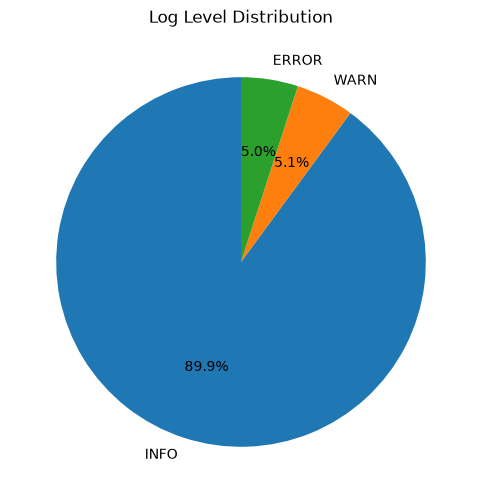

In [358]:
level_counts = df["level"].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(level_counts, labels=level_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Log Level Distribution")
plt.savefig("../Data/level_pie.png")
plt.show()

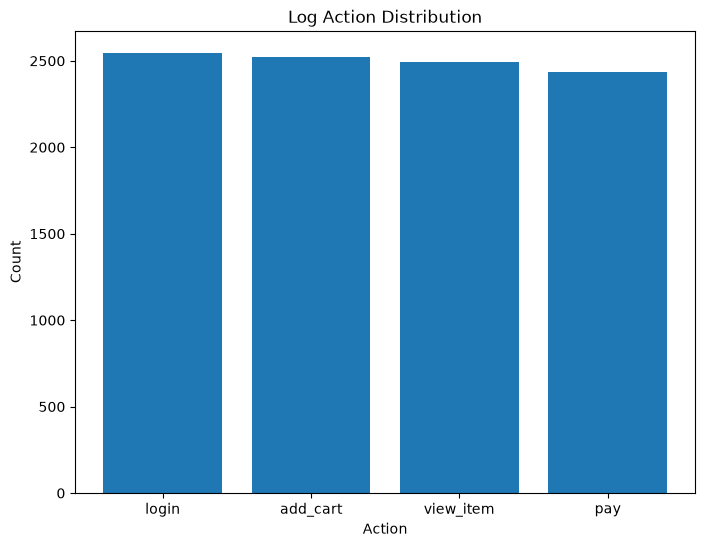

In [359]:
action_counts = df["action"].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(action_counts.index, action_counts)
plt.xlabel("Action")
plt.ylabel("Count")
plt.title("Log Action Distribution")
plt.savefig("../Data/action_bar.png")
plt.show()

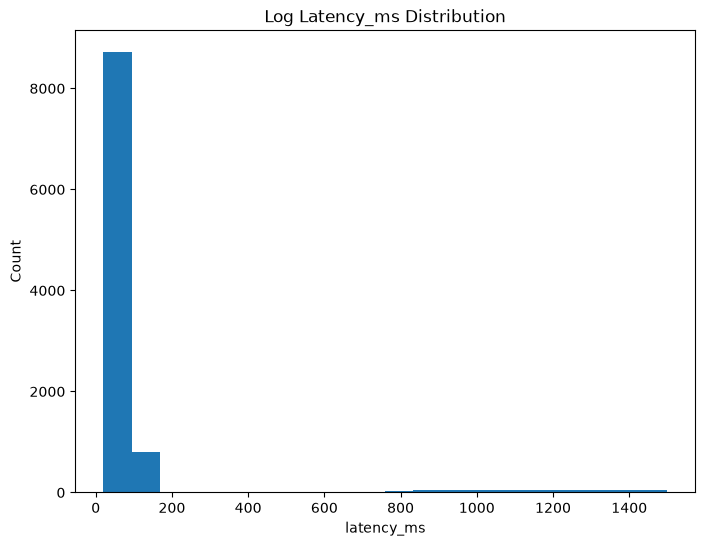

In [360]:
plt.figure(figsize=(8, 6))
plt.hist(df["latency_ms"], bins=20)
plt.xlabel("latency_ms")
plt.ylabel("Count")
plt.title("Log Latency_ms Distribution")
plt.savefig("../Data/latency_hist.png")
plt.show()

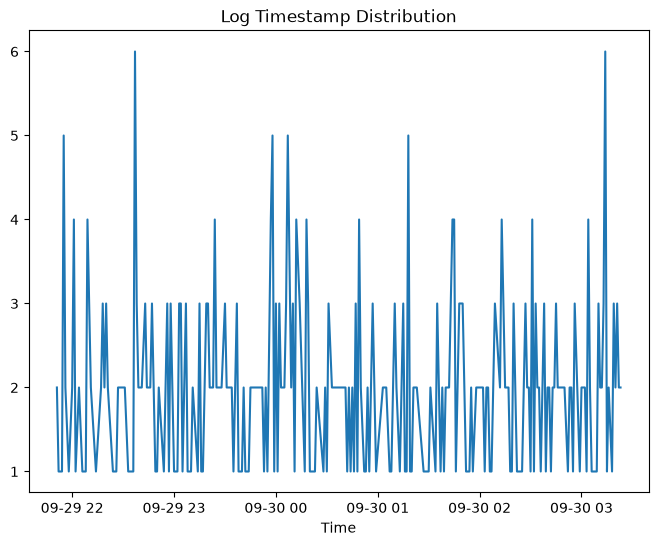

In [361]:
df["time"] = pd.to_datetime(df["timestamp"])
error_df = df[df["level"] == "ERROR"]
minute_counts = error_df.groupby(error_df["time"].dt.floor("min")).size()
plt.figure(figsize = (8, 6))
plt.plot(minute_counts.index, minute_counts.values)
plt.xlabel("Time")
plt.title("Log Timestamp Distribution")
plt.savefig("../Data/timestamp_error.png")
plt.show()

In [362]:
df["time"] = pd.to_datetime(df["timestamp"])
df = df.set_index("time")
df.index

DatetimeIndex(['2026-09-29 21:50:37', '2026-09-29 21:50:39',
               '2026-09-29 21:50:42', '2026-09-29 21:50:45',
               '2026-09-29 21:50:48', '2026-09-29 21:50:49',
               '2026-09-29 21:50:50', '2026-09-29 21:50:52',
               '2026-09-29 21:50:54', '2026-09-29 21:50:56',
               ...
               '2026-09-30 03:23:56', '2026-09-30 03:23:59',
               '2026-09-30 03:24:00', '2026-09-30 03:24:02',
               '2026-09-30 03:24:03', '2026-09-30 03:24:06',
               '2026-09-30 03:24:09', '2026-09-30 03:24:10',
               '2026-09-30 03:24:11', '2026-09-30 03:24:12'],
              dtype='datetime64[us]', name='time', length=10000, freq=None)

In [363]:
error_counts = (df["level"] == "ERROR").resample("10min").sum()
p95_latency = df["latency_ms"].resample("10min").quantile(0.95)
error_counts.head(10)

time
2026-09-29 21:50:00    13
2026-09-29 22:00:00    15
2026-09-29 22:10:00    10
2026-09-29 22:20:00    10
2026-09-29 22:30:00    16
2026-09-29 22:40:00    17
2026-09-29 22:50:00    15
2026-09-29 23:00:00    14
2026-09-29 23:10:00    14
2026-09-29 23:20:00    19
Freq: 10min, Name: level, dtype: int64

In [364]:
window_size = 3
roll_mean = error_counts.rolling(window=window_size, min_periods=1).mean()
roll_std = error_counts.rolling(window=window_size, min_periods=1).std()
threshold = roll_mean + 2 * roll_std
roll_mean.head()

time
2026-09-29 21:50:00    13.000000
2026-09-29 22:00:00    14.000000
2026-09-29 22:10:00    12.666667
2026-09-29 22:20:00    11.666667
2026-09-29 22:30:00    12.000000
Freq: 10min, Name: level, dtype: float64

In [365]:
is_anomaly = error_counts > threshold.fillna(error_counts.mean())
anomalies = error_counts[is_anomaly]
print(f" !!! 发现 {len(anomalies)} 个异常时间点")
anomalies

 !!! 发现 0 个异常时间点


Series([], Freq: 10min, Name: level, dtype: int64)

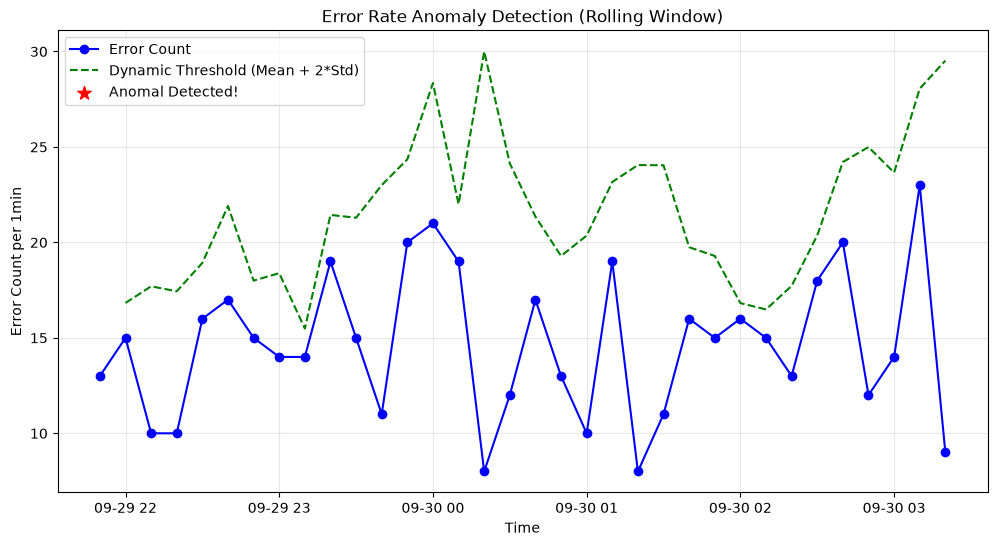

In [366]:
plt.figure(figsize=(12, 6))
plt.plot(error_counts.index, error_counts.values, label="Error Count", color="blue", marker="o")
plt.plot(threshold.index, threshold.values, label="Dynamic Threshold (Mean + 2*Std)", color="green", linestyle="--")
plt.scatter(anomalies.index, anomalies.values, color="red", s=100, marker="*", label="Anomal Detected!", zorder=5)
plt.title("Error Rate Anomaly Detection (Rolling Window)")
plt.xlabel("Time")
plt.ylabel("Error Count per 1min")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("../Data/anomaly_detection.png")
plt.show()

In [367]:
conn.close()